In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

In [2]:
from utils import evaluate_across_gws, select_features_by_correlation, tune_best_model

In [3]:
player_data = pd.read_csv('../rolled_data_24_25.csv', index_col=False)

avail_feats = [
 'was_home',
 'value',
 'transfers_balance',
 'selected',
 'transfers_in',
 'transfers_out',
 'difficulty',
 'opponent_difficulty',
 'win_prob',
 'percentage_net_transfers',
 'xP',
 'elo_diff',
 'ownership_change',
 'points_rolling_1',
 'points_rolling_3',
 'points_rolling_5',
 'xP_rolling_1',
 'xP_rolling_3',
 'xP_rolling_5',
 'minutes_rolling_1',
 'minutes_rolling_3',
 'minutes_rolling_5',
 'clean_sheets_rolling_1',
 'clean_sheets_rolling_3',
 'clean_sheets_rolling_5',
 'goals_conceded_rolling_1',
 'goals_conceded_rolling_3',
 'goals_conceded_rolling_5',
 'yellow_cards_rolling_1',
 'yellow_cards_rolling_3',
 'yellow_cards_rolling_5',
 'saves_rolling_1',
 'saves_rolling_3',
 'saves_rolling_5',
 'influence_rolling_1',
 'influence_rolling_3',
 'influence_rolling_5',
 'creativity_rolling_1',
 'creativity_rolling_3',
 'creativity_rolling_5',
 'threat_rolling_1',
 'threat_rolling_3',
 'threat_rolling_5',
 'ict_index_rolling_1',
 'ict_index_rolling_3',
 'ict_index_rolling_5',
 'starts_rolling_1',
 'starts_rolling_3',
 'starts_rolling_5',
 'expected_goal_involvements_rolling_1',
 'expected_goal_involvements_rolling_3',
 'expected_goal_involvements_rolling_5',
 'expected_goals_conceded_rolling_1',
 'expected_goals_conceded_rolling_3',
 'expected_goals_conceded_rolling_5',
 'interceptions_rolling_1',
 'interceptions_rolling_3',
 'interceptions_rolling_5',
 'blocks_rolling_1',
 'blocks_rolling_3',
 'blocks_rolling_5',
 'clearances_rolling_1',
 'clearances_rolling_3',
 'clearances_rolling_5',
 'tackles_rolling_1',
 'tackles_rolling_3',
 'tackles_rolling_5',
 'chances_created_rolling_1',
 'chances_created_rolling_3',
 'chances_created_rolling_5',
 'goals_prevented_rolling_1',
 'goals_prevented_rolling_3',
 'goals_prevented_rolling_5',
 'sweeper_actions_rolling_1',
 'sweeper_actions_rolling_3',
 'sweeper_actions_rolling_5',
 'tackles_won_percent_rolling_1',
 'tackles_won_percent_rolling_3',
 'tackles_won_percent_rolling_5',
 'opponent_xG_rolling_1',
 'opponent_xG_rolling_3',
 'opponent_xG_rolling_5',
 'opponent_xGOT_rolling_1',
 'opponent_xGOT_rolling_3',
 'opponent_xGOT_rolling_5',
 'shots_faced_rolling_1',
 'shots_faced_rolling_3',
 'shots_faced_rolling_5',
 'opponent_shots_faced_rolling_1',
 'opponent_shots_faced_rolling_3',
 'opponent_shots_faced_rolling_5',
 'big_chances_faced_rolling_1',
 'big_chances_faced_rolling_3',
 'big_chances_faced_rolling_5',
 'opponent_big_chances_faced_rolling_1',
 'opponent_big_chances_faced_rolling_3',
 'opponent_big_chances_faced_rolling_5',
 'total_points_per_90_rolling_1',
 'total_points_per_90_rolling_3',
 'total_points_per_90_rolling_5',
 'clean_sheets_per_90_rolling_1',
 'clean_sheets_per_90_rolling_3',
 'clean_sheets_per_90_rolling_5',
 'goals_conceded_per_90_rolling_1',
 'goals_conceded_per_90_rolling_3',
 'goals_conceded_per_90_rolling_5',
 'saves_per_90_rolling_1',
 'saves_per_90_rolling_3',
 'saves_per_90_rolling_5',
 'expected_goal_involvements_per_90_rolling_1',
 'expected_goal_involvements_per_90_rolling_3',
 'expected_goal_involvements_per_90_rolling_5',
 'expected_goals_conceded_per_90_rolling_1',
 'expected_goals_conceded_per_90_rolling_3',
 'expected_goals_conceded_per_90_rolling_5',
 'interceptions_per_90_rolling_1',
 'interceptions_per_90_rolling_3',
 'interceptions_per_90_rolling_5',
 'blocks_per_90_rolling_1',
 'blocks_per_90_rolling_3',
 'blocks_per_90_rolling_5',
 'clearances_per_90_rolling_1',
 'clearances_per_90_rolling_3',
 'clearances_per_90_rolling_5',
 'tackles_per_90_rolling_1',
 'tackles_per_90_rolling_3',
 'tackles_per_90_rolling_5',
 'chances_created_per_90_rolling_1',
 'chances_created_per_90_rolling_3',
 'chances_created_per_90_rolling_5',
 'goals_prevented_per_90_rolling_1',
 'goals_prevented_per_90_rolling_3',
 'goals_prevented_per_90_rolling_5',
 'sweeper_actions_per_90_rolling_1',
 'sweeper_actions_per_90_rolling_3',
 'sweeper_actions_per_90_rolling_5',
 'tackles_won_percent_per_90_rolling_1',
 'tackles_won_percent_per_90_rolling_3',
 'tackles_won_percent_per_90_rolling_5',
 'points_1_ewm',
 'points_3_ewm',
 'points_5_ewm',
 'xP_1_ewm',
 'xP_3_ewm',
 'xP_5_ewm',
 'minutes_1_ewm',
 'minutes_3_ewm',
 'minutes_5_ewm',
 'clean_sheets_1_ewm',
 'clean_sheets_3_ewm',
 'clean_sheets_5_ewm',
 'goals_conceded_1_ewm',
 'goals_conceded_3_ewm',
 'goals_conceded_5_ewm',
 'yellow_cards_1_ewm',
 'yellow_cards_3_ewm',
 'yellow_cards_5_ewm',
 'saves_1_ewm',
 'saves_3_ewm',
 'saves_5_ewm',
 'influence_1_ewm',
 'influence_3_ewm',
 'influence_5_ewm',
 'creativity_1_ewm',
 'creativity_3_ewm',
 'creativity_5_ewm',
 'threat_1_ewm',
 'threat_3_ewm',
 'threat_5_ewm',
 'ict_index_1_ewm',
 'ict_index_3_ewm',
 'ict_index_5_ewm',
 'starts_1_ewm',
 'starts_3_ewm',
 'starts_5_ewm',
 'expected_goal_involvements_1_ewm',
 'expected_goal_involvements_3_ewm',
 'expected_goal_involvements_5_ewm',
 'expected_goals_conceded_1_ewm',
 'expected_goals_conceded_3_ewm',
 'expected_goals_conceded_5_ewm',
 'interceptions_1_ewm',
 'interceptions_3_ewm',
 'interceptions_5_ewm',
 'blocks_1_ewm',
 'blocks_3_ewm',
 'blocks_5_ewm',
 'clearances_1_ewm',
 'clearances_3_ewm',
 'clearances_5_ewm',
 'tackles_1_ewm',
 'tackles_3_ewm',
 'tackles_5_ewm',
 'chances_created_1_ewm',
 'chances_created_3_ewm',
 'chances_created_5_ewm',
 'goals_prevented_1_ewm',
 'goals_prevented_3_ewm',
 'goals_prevented_5_ewm',
 'sweeper_actions_1_ewm',
 'sweeper_actions_3_ewm',
 'sweeper_actions_5_ewm',
 'tackles_won_percent_1_ewm',
 'tackles_won_percent_3_ewm',
 'tackles_won_percent_5_ewm',
 'opponent_xG_1_ewm',
 'opponent_xG_3_ewm',
 'opponent_xG_5_ewm',
 'opponent_xGOT_1_ewm',
 'opponent_xGOT_3_ewm',
 'opponent_xGOT_5_ewm',
 'shots_faced_1_ewm',
 'shots_faced_3_ewm',
 'shots_faced_5_ewm',
 'opponent_shots_faced_1_ewm',
 'opponent_shots_faced_3_ewm',
 'opponent_shots_faced_5_ewm',
 'big_chances_faced_1_ewm',
 'big_chances_faced_3_ewm',
 'big_chances_faced_5_ewm',
 'opponent_big_chances_faced_1_ewm',
 'opponent_big_chances_faced_3_ewm',
 'opponent_big_chances_faced_5_ewm',
 'total_points_per_90_1_ewm',
 'total_points_per_90_3_ewm',
 'total_points_per_90_5_ewm',
 'clean_sheets_per_90_1_ewm',
 'clean_sheets_per_90_3_ewm',
 'clean_sheets_per_90_5_ewm',
 'goals_conceded_per_90_1_ewm',
 'goals_conceded_per_90_3_ewm',
 'goals_conceded_per_90_5_ewm',
 'saves_per_90_1_ewm',
 'saves_per_90_3_ewm',
 'saves_per_90_5_ewm',
 'expected_goal_involvements_per_90_1_ewm',
 'expected_goal_involvements_per_90_3_ewm',
 'expected_goal_involvements_per_90_5_ewm',
 'expected_goals_conceded_per_90_1_ewm',
 'expected_goals_conceded_per_90_3_ewm',
 'expected_goals_conceded_per_90_5_ewm',
 'interceptions_per_90_1_ewm',
 'interceptions_per_90_3_ewm',
 'interceptions_per_90_5_ewm',
 'blocks_per_90_1_ewm',
 'blocks_per_90_3_ewm',
 'blocks_per_90_5_ewm',
 'clearances_per_90_1_ewm',
 'clearances_per_90_3_ewm',
 'clearances_per_90_5_ewm',
 'tackles_per_90_1_ewm',
 'tackles_per_90_3_ewm',
 'tackles_per_90_5_ewm',
 'chances_created_per_90_1_ewm',
 'chances_created_per_90_3_ewm',
 'chances_created_per_90_5_ewm',
 'goals_prevented_per_90_1_ewm',
 'goals_prevented_per_90_3_ewm',
 'goals_prevented_per_90_5_ewm',
 'sweeper_actions_per_90_1_ewm',
 'sweeper_actions_per_90_3_ewm',
 'sweeper_actions_per_90_5_ewm',
 'tackles_won_percent_per_90_1_ewm',
 'tackles_won_percent_per_90_3_ewm',
 'tackles_won_percent_per_90_5_ewm'
]

data = player_data[player_data['position'] == 'Goalkeeper']

# GK


In [ ]:
feats = {}
for round in range(6, 39):
    curr = data[(data['round'] > 3) & (data['round'] < round)].fillna(0)
    if round in [22, 32, 34]:
        continue
    if round >= 22:
        curr = curr[curr['round'] != 22]
    if round >= 32:
            curr = curr[curr['round'] != 32]
    if round >= 34:
            curr = curr[curr['round'] != 34]


    feats_selected = select_features_by_correlation(curr, avail_feats)
    feats[round] = feats_selected

feats

  dropping 'total_points_per_90_rolling_3' (|corr| with xP=0.899) -- |corr|=0.899 with already-selected 'xP'
  dropping 'points_rolling_3' (|corr| with xP=0.897) -- |corr|=0.897 with already-selected 'xP'
  dropping 'points_3_ewm' (|corr| with xP=0.897) -- |corr|=0.897 with already-selected 'xP'
  dropping 'points_5_ewm' (|corr| with xP=0.895) -- |corr|=0.895 with already-selected 'xP'
  dropping 'total_points_per_90_5_ewm' (|corr| with xP=0.894) -- |corr|=0.894 with already-selected 'xP'
  dropping 'total_points_per_90_3_ewm' (|corr| with xP=0.891) -- |corr|=0.891 with already-selected 'xP'
  dropping 'xP_rolling_1' (|corr| with xP=0.849) -- |corr|=0.849 with already-selected 'xP'
  dropping 'xP_1_ewm' (|corr| with xP=0.849) -- |corr|=0.849 with already-selected 'xP'
  dropping 'xP_3_ewm' (|corr| with xP=0.823) -- |corr|=0.823 with already-selected 'xP'
  dropping 'minutes_rolling_3' (|corr| with xP=0.810) -- |corr|=0.810 with already-selected 'xP'
  dropping 'minutes_3_ewm' (|corr| w

{6: ['was_home',
  'transfers_in',
  'transfers_out',
  'difficulty',
  'opponent_difficulty',
  'xP',
  'elo_diff',
  'yellow_cards_rolling_3',
  'expected_goal_involvements_rolling_1',
  'expected_goal_involvements_rolling_3',
  'tackles_rolling_3',
  'interceptions_per_90_rolling_1',
  'interceptions_per_90_rolling_3',
  'chances_created_per_90_rolling_3',
  'sweeper_actions_per_90_rolling_3',
  'clean_sheets_1_ewm',
  'expected_goals_conceded_1_ewm',
  'tackles_1_ewm',
  'goals_prevented_3_ewm',
  'opponent_xG_5_ewm',
  'big_chances_faced_5_ewm'],
 7: ['was_home',
  'transfers_in',
  'transfers_out',
  'difficulty',
  'opponent_difficulty',
  'percentage_net_transfers',
  'xP',
  'elo_diff',
  'yellow_cards_rolling_3',
  'creativity_rolling_5',
  'interceptions_rolling_1',
  'interceptions_rolling_3',
  'tackles_rolling_1',
  'goals_prevented_rolling_5',
  'opponent_big_chances_faced_rolling_5',
  'total_points_per_90_rolling_5',
  'clean_sheets_per_90_rolling_1',
  'interceptions_

In [5]:
joblib.dump(feats, './hist/feats_gk')

['./hist/feats_gk']

## Models


In [7]:
models_by_round = {}
mae_by_round = {}
r2_by_round = {}
tuned_models = []

for round in range(5,38):
    # Multi-gameweek comparison (more robust signal, recommended)
    print(f"\n=== Averaged across rounds {3}-{round} ===")

    feats_round = feats[round+1]
    # print(feats_round)
    feats_round = feats_round + ['round', 'element','was_home']

    # Step 1: compare models across several rounds
    combined, summary = evaluate_across_gws(data[feats_round], gw_list=range(3,round+1))
    print(summary.to_string(index=False))

    base_name = summary.sort_values("MAE").iloc[0]["model"]
    base_mae = summary.sort_values("MAE").iloc[0]["MAE"]
    base_r2 = summary.sort_values("MAE").iloc[0]["R2"]

    # Step 2: tune the winner, validating on rounds 6-round, holding out round+1
    best_model, best_estimator, search, c_final, mae, rmse, r2 = tune_best_model(
        data[feats_round],
        summary,
        val_gws=range(1,round),
        final_test_gw=round+1,
        n_iter=40,
    )

    if mae > base_mae:
        # mae_by_round[round+1] = mae
        models_by_round[round+1] = {
            'mae': mae,
            'r2': r2,
            "best_model": best_model,
            "c_final": c_final,
            "best_estimator": best_estimator,
            "search": search
        }
    else:
        # mae_by_round[round+1] = base_mae
        models_by_round[round+1] = {
            'mae': base_mae,
            'r2': base_r2,
            "best_model": base_name,
            "c_final": c_final
        }



=== Averaged across rounds 3-5 ===
               model      MAE     RMSE       R2
        RandomForest 0.578434 0.952209 0.720959
            LightGBM 0.648214 1.024817 0.680795
HistGradientBoosting 0.657863 1.028888 0.677987
Best model from comparison: RandomForest
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV MAE: 0.998
Best params:
  regressor__max_depth: 10
  regressor__max_features: sqrt
  regressor__min_samples_leaf: 2
  regressor__min_samples_split: 3
  regressor__n_estimators: 319

Holdout (round 6) performance:
  MAE=0.460  RMSE=0.739  R2=0.814

=== Averaged across rounds 3-6 ===
               model      MAE     RMSE       R2
        RandomForest 0.568633 0.918647 0.734390
HistGradientBoosting 0.602230 0.933091 0.728264
            LightGBM 0.637432 0.996643 0.689488
Best model from comparison: RandomForest
Fitting 4 folds for each of 40 candidates, totalling 160 fits

Best CV MAE: 0.897
Best params:
  regressor__max_depth: 10
  regressor__max_featu

In [8]:
# models_by_round.values() #['mae']

mae_by_round = {}
r2_by_round = {}
for ro in range(7, 39):
    mae_by_round[ro] = models_by_round[ro]['mae']
    r2_by_round[ro] = models_by_round[ro]['r2']

mae_by_round

{7: 0.5831463848346243,
 8: 0.644572749909426,
 9: 0.5751705186719159,
 10: 0.6021716300371475,
 11: 0.5667919842361556,
 12: 0.5492606227588746,
 13: 0.5583775674487501,
 14: 0.5670793901055972,
 15: 0.5354138530178337,
 16: 0.5183592852988163,
 17: 0.513309998183595,
 18: 0.513823008805662,
 19: 0.5012435612815679,
 20: 0.4896049054206261,
 21: 0.5085694351958953,
 22: 1.6527367978359908,
 23: 0.5540829444033389,
 24: 0.5443150305366403,
 25: 0.7133799656456821,
 26: 0.5628332718895745,
 27: 0.5609764527596507,
 28: 0.5523661446816063,
 29: 0.5498288829765141,
 30: 0.6362081159917058,
 31: 0.563563522675288,
 32: 1.745506854370475,
 33: 0.767853331763079,
 34: 1.5635312861541,
 35: 0.6277765330905499,
 36: 0.6300355362253711,
 37: 0.6293806533748771,
 38: 0.623113317727094}

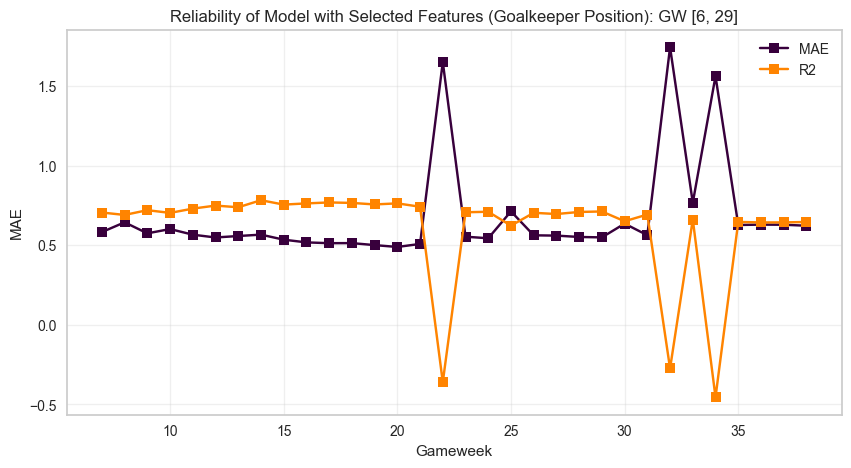

In [9]:
# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(mae_by_round.keys(), mae_by_round.values(), marker='s', color="#38003c", label='MAE')

plt.plot(r2_by_round.keys(), r2_by_round.values(), marker='s', color="#ff8400", label='R2')
plt.title('Reliability of Model with Selected Features (Goalkeeper Position): GW [6, 29]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [10]:
joblib.dump(models_by_round, './models_by_round_gk')

['./models_by_round_gk']